In [215]:
import torch
import matplotlib.pyplot as plt
import torch.nn as nn
import numpy as np

In [216]:
device = 'mps' if torch.backends.mps.is_available() else 'cpu'
device

'mps'

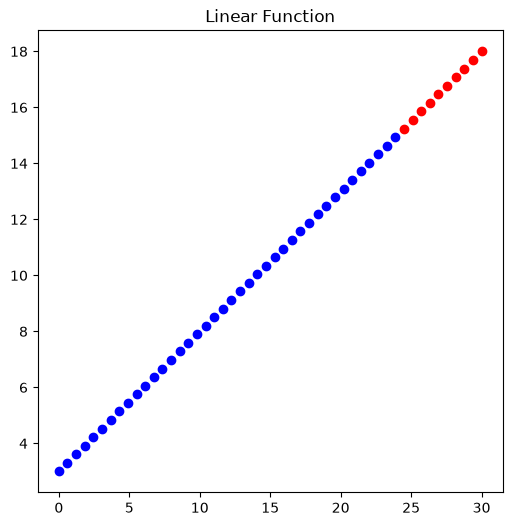

In [217]:
a = 0.5
b = 3

x = torch.linspace(0,30,50).unsqueeze(1)
y = a*x + b

data_size = x.size()[0]
ratio = int(data_size*0.8)
x_train = x[:ratio]
y_train = y[:ratio]

x_test = x[ratio:]
y_test = y[ratio:]

plt.figure(1, figsize=(6,6))
plt.scatter(x_train,y_train, c='b', marker='o', label='Train')
plt.scatter(x_test,y_test, c='r', marker='o', label='Test')
plt.title('Linear Function')
plt.show()

In [218]:
class LinearFunctionRegression(nn.Module):
    def __init__(self):
        super().__init__()

        self.weights = nn.Parameter(torch.randn(1))
        self.bias = nn.Parameter(torch.randn(1))

    def forward(self, x):
        return self.weights*x + self.bias

In [219]:
model = LinearFunctionRegression()

loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

In [220]:
x_train = x_train.to(device)
y_train = y_train.to(device)
x_test = x_test.to(device)
y_test = y_test.to(device)
model = model.to(device)

In [ ]:
epochs = 100
losses_train = []
losses_test = []

for epoch in range(epochs):
    model.train()

    y_pred = model(x_train)
    loss = loss_fn(y_pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses_train.append(loss.item())

    model.eval()
    with torch.inference_mode():
        y_pred = model(x_test)
        loss = loss_fn(y_pred, y_test)
        losses_test.append(loss.item())

    print(f'Epoch {epoch+1}/{epochs}, Training/Test Loss: {losses_train[-1]} {losses_test[-1]}')

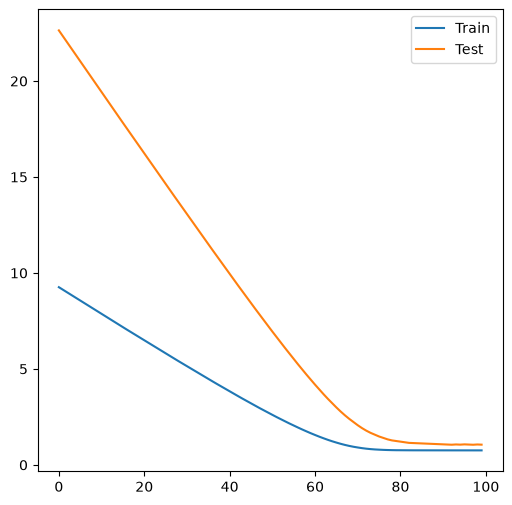

In [222]:
plt.figure(1, figsize=(6,6))
plt.plot(losses_train, label='Train')
plt.plot(losses_test, label='Test')
plt.legend()
plt.show()

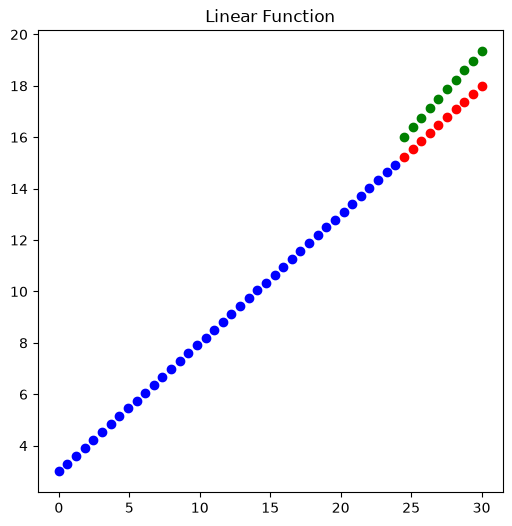

In [223]:
model.eval()
with torch.no_grad():
    y_preds = model(x_test)

plt.figure(1, figsize=(6,6))
plt.scatter(x_train.cpu(),y_train.cpu(), c='b', marker='o', label='Train')
plt.scatter(x_test.cpu(),y_test.cpu(), c='r', marker='o', label='Train')
plt.scatter(x_test.cpu(),y_preds.cpu(), c='g', marker='o', label='Test')
plt.title('Linear Function')
plt.show()

In [224]:
list(model.parameters())

[Parameter containing:
 tensor([0.6044], device='mps:0', requires_grad=True),
 Parameter containing:
 tensor([1.2096], device='mps:0', requires_grad=True)]